In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [2]:
import pandas as pd

df = pd.read_parquet("/Users/bsama/Desktop/emotion recognition/0000.parquet")

print(df.columns)
print(df.head())
print(df.shape)

Index(['img_bytes', 'labels'], dtype='object')
                                           img_bytes  labels
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...       0
(35887, 2)


In [3]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())

2.10.0
True


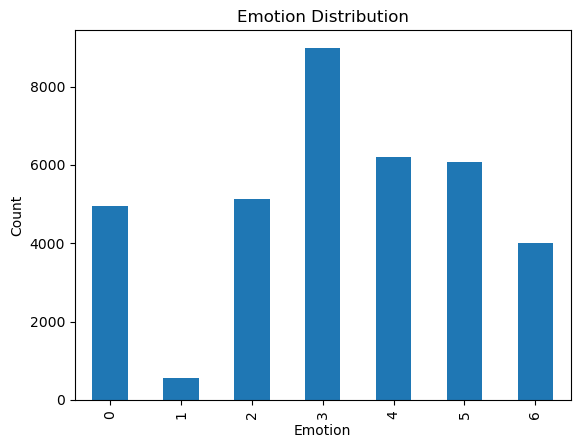

In [4]:
import matplotlib.pyplot as plt

df["labels"].value_counts().sort_index().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [5]:
print(df["labels"].value_counts().sort_index())

labels
0    4953
1     547
2    5121
3    8989
4    6198
5    6077
6    4002
Name: count, dtype: int64


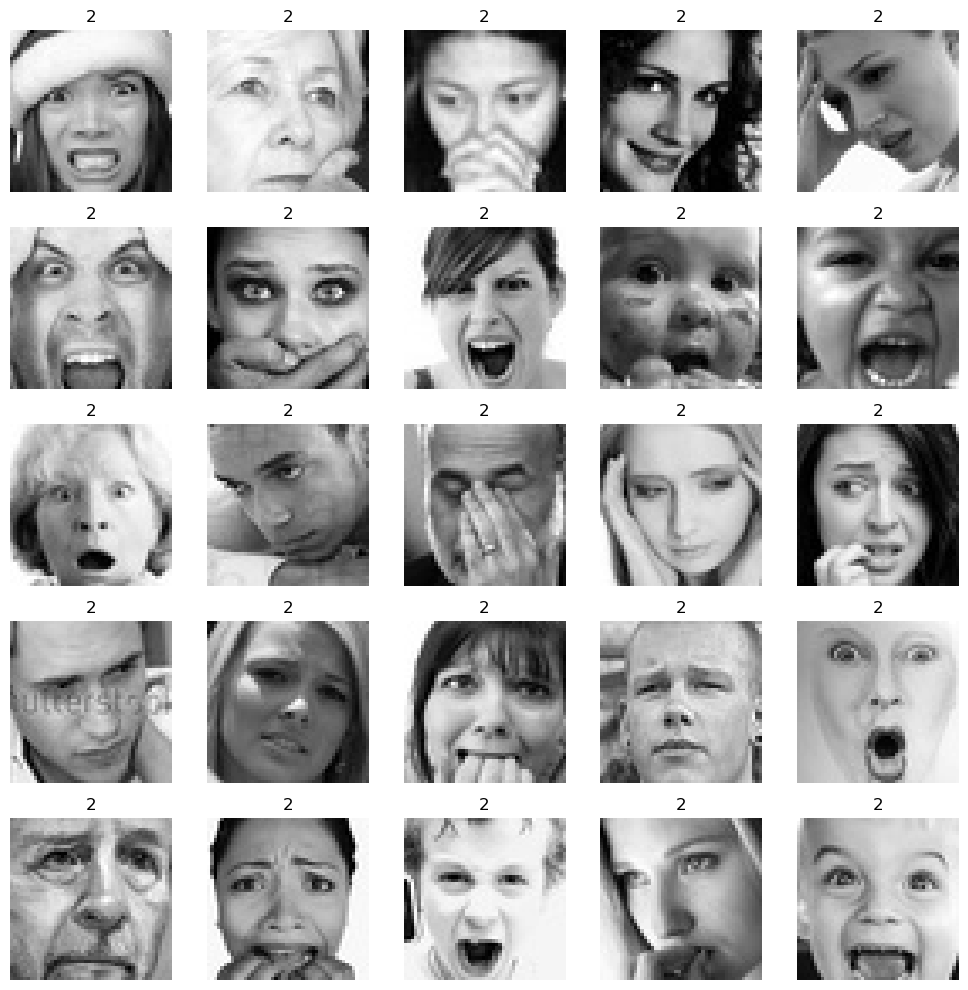

In [6]:
import random

label_to_show = 2

filtered = df[df["labels"] == label_to_show]

plt.figure(figsize=(10,10))

for i in range(25):
    idx = random.randint(0, len(filtered)-1)
    img_bytes = filtered.iloc[idx]["img_bytes"]
    img = Image.open(io.BytesIO(img_bytes))

    plt.subplot(5,5,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(label_to_show)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
images = []
labels = []

for i in range(len(df)):
    img_bytes = df.iloc[i]["img_bytes"]
    label = df.iloc[i]["labels"]

    img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    img = img.resize((48,48))

    images.append(np.array(img))
    labels.append(label)

X = np.array(images)
y = np.array(labels)

print(X.shape, y.shape)

(35887, 48, 48, 3) (35887,)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(28709, 48, 48, 3) (7178, 48, 48, 3)


In [9]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),   # for MobileNet
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

In [10]:
class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [11]:
train_dataset = EmotionDataset(X_train, y_train, train_transform)
val_dataset = EmotionDataset(X_val, y_val, val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [12]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using:", device)

Using: mps


In [13]:
model = models.mobilenet_v3_small(pretrained=True)

# change final layer to 7 classes
model.classifier[3] = nn.Linear(model.classifier[3].in_features, 7)

model = model.to(device)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/bsama/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████████████████████████████████| 9.83M/9.83M [00:00<00:00, 18.8MB/s]


In [14]:
class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [18]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1} loss:", total_loss)
    
    # validation accuracy
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct/total
    print(f"Validation accuracy: {acc:.2f}%")

100%|█████████████████████████████████████████| 449/449 [00:52<00:00,  8.49it/s]



Epoch 1 loss: 332.9141853749752
Validation accuracy: 62.76%


100%|█████████████████████████████████████████| 449/449 [00:53<00:00,  8.39it/s]



Epoch 2 loss: 302.12032401561737
Validation accuracy: 64.86%


100%|█████████████████████████████████████████| 449/449 [00:54<00:00,  8.26it/s]


...


Epoch 18 loss: 74.91727222129703
Validation accuracy: 65.91%


100%|█████████████████████████████████████████| 449/449 [00:54<00:00,  8.18it/s]



Epoch 19 loss: 68.83355074189603
Validation accuracy: 66.52%


100%|█████████████████████████████████████████| 449/449 [00:54<00:00,  8.19it/s]



Epoch 20 loss: 62.06792111136019
Validation accuracy: 66.08%


In [19]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = criterion(pred,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1} loss:", total_loss)

    # validation accuracy
    model.eval()
    correct,total = 0,0

    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb = xb.to(device), yb.to(device)
            pred = model(xb)
            _,p = torch.max(pred,1)

            correct += (p==yb).sum().item()
            total += yb.size(0)

    acc = 100*correct/total
    print("Validation accuracy:", acc)



Epoch 1 loss: 61.709178326651454
Validation accuracy: 65.7286152131513

Epoch 2 loss: 60.517314181663096
Validation accuracy: 64.80913903594316

Epoch 3 loss: 57.60749300010502
Validation accuracy: 66.29980495959877

Epoch 4 loss: 51.893350574187934
Validation accuracy: 65.75647812761216

Epoch 5 loss: 48.8028321089223
Validation accuracy: 65.63109501253831
